# Михельсон Владимир 316 Практикум 2

Дальнейший анализ будем проводить с использованием датасета из предыдущего задания и с использованием синтетических нормальных данных, там, где нормальность требуется

## 1.Критерии Стьюдента, Уилкоксона-Манна-Уитни, Фишера, Левене, Бартлетта, Флигнера-Килина

### а. Критерий Стьюдента

<b>Критерий Стьюдента</b> (t-критерий) - это статистический метод, предназначенный для проверки гипотез о значимости различий между средними значениями. Он применяется в тех случаях, когда данные имеют количественный характер (например, рост, вес, концентрация вещества, баллы по тесту), а распределение признака в генеральной совокупности предполагается нормальным или близким к нему.

Ключевой особенностью t-критерия является его эффективность при работе с малыми выборками (объемом, как правило, до 30-60 наблюдений).

In [1]:
library(pwr)

n <- 100
mean1 <- 10
mean2 <- 30
std1 <- 100
std2 <- 100

set.seed(41)
sample1 <- rnorm(n, mean = mean1, sd = std1)
sample2 <- rnorm(n, mean = mean2, sd = std2)

t_test_result <- t.test(sample1, sample2, var.equal = TRUE)
pooled_std <- sqrt((std1^2 + std2^2) / 2)
effect_size <- (mean2 - mean1) / pooled_std

desired_power <- 0.8

cat("Двухсторонний t-тест\n")
cat(sprintf("t-статистика: %.4f\n", t_test_result$statistic))
cat(sprintf("p-значение: %.4f\n", t_test_result$p.value))

power <- pwr.t.test(d = effect_size, n = n, sig.level = 0.1, type = "two.sample", alternative = "two.sided")$power
required_sample_size <- pwr.t.test(d = effect_size, power = desired_power, sig.level = 0.1, type = "two.sample", alternative = "two.sided")$n

cat(sprintf("Мощность: %.4f\n", power))
cat(sprintf("Необходимый объем выборки для мощности 0.8: %.4f\n", required_sample_size))

t_test_result_one_sided <- t.test(sample1, sample2, var.equal = TRUE, alternative = "greater")
cat("\nОдносторонний t-тест (Средние sample 1 < sample2)\n")
cat(sprintf("t-статистика: %.4f\n", t_test_result_one_sided$statistic))
cat(sprintf("p-значение: %.4f\n", t_test_result_one_sided$p.value))

power_one_sided <- pwr.t.test(d = effect_size, n = n, sig.level = 0.1, type = "two.sample", alternative = "greater")$power
required_sample_size_one_sided <- pwr.t.test(d = effect_size, power = desired_power, sig.level = 0.1, type = "two.sample", alternative = "greater")$n

cat(sprintf("Мощность: %.4f\n", power_one_sided))
cat(sprintf("Необходимый объем выборки для мощности 0.8: %.4f\n", required_sample_size_one_sided))

Двухсторонний t-тест
t-статистика: -0.0105
p-значение: 0.9917
Мощность: 0.4080
Необходимый объем выборки для мощности 0.8: 309.7905

Односторонний t-тест (Средние sample 1 < sample2)
t-статистика: -0.0105
p-значение: 0.5042
Мощность: 0.5516
Необходимый объем выборки для мощности 0.8: 225.8057


### b. Уилкоксона-Манна-Уитни

<b>Описание теста:</b> тест Уилкоксона-Манна-Уитни это непараметрический метод для проверки гипотезы о равенстве распределений двух независимых выборок.
- <b>$H_0$:</b> Распределения двух групп идентичны.  
- <b>$H_1$:</b> Распределения отличаются.

Данный тест не требует нормальности данных, поэтому может быть применён к реальным данным.

<b>Условия применимости</b>

Независимые выборки - наблюдения в одной выборке не должны быть связаны с наблюдениями в другой

Порядковая шкала или выше - данные должны иметь смысл ранжирования

Независимость наблюдений внутри каждой выборки

Форма распределения - распределения должны быть схожей формы (но не обязательно нормальные)

In [2]:
library(readr)

file_path <- 'winequality-red.csv'
data <- read_csv(file_path, show_col_types = FALSE)

# Находим медиану содержания алкоголя
median_alcohol <- median(data$alcohol)

# Берем две случайные выборки из одних и тех же данных
set.seed(41)
quality1 <- data[sample(nrow(data), 100), ]
set.seed(410)
quality2 <- data[sample(nrow(data), 100), ]

# Тест Манна-Уитни для случайных выборок
test_random <- wilcox.test(quality1$quality, quality2$quality, exact = FALSE)

# Основное исследование - разделение данных по медиане алкоголя
quality_small <- data[data$alcohol <= median_alcohol, ]
quality_large <- data[data$alcohol > median_alcohol, ]

# Отбор выборок из двух групп
sample_size <- 100
set.seed(41)
small_sample <- quality_small[sample(nrow(quality_small), sample_size), ]
set.seed(41)
large_sample <- quality_large[sample(nrow(quality_large), sample_size), ]

# Тест Манна-Уитни для основных групп
test_main <- wilcox.test(small_sample$quality, large_sample$quality, alternative = "two.sided", exact = FALSE)

# Функция для красивого вывода
nice_scientific_notation <- function(number, decimals = 2) {
  sci_notation <- formatC(number, format = "e", digits = decimals)
  parts <- strsplit(sci_notation, "e")[[1]]
  base <- parts[1]
  exponent <- as.integer(parts[2])
  
  # Убираем лишние нули в экспоненте
  if (exponent >= 0) {
    exp_str <- as.character(exponent)
  } else {
    exp_str <- paste0("-", as.character(abs(exponent)))
  }
  
  return(paste0(base, " × 10^", exp_str))
}

cat("Результаты U-теста Манна-Уитни для случайных выборок (quality1 vs quality2):\n")
cat(sprintf("Статистика U: %.4f\n", test_random$statistic))
cat(sprintf("p-значение: %.4f\n\n", test_random$p.value))

cat("Результаты U-теста Манна-Уитни для групп (низкий vs высокий алкоголь):\n")
cat(sprintf("Статистика U: %.4f\n", test_main$statistic))
cat(sprintf("p-значение: %s\n", nice_scientific_notation(test_main$p.value, 2)))

Результаты U-теста Манна-Уитни для случайных выборок (quality1 vs quality2):
Статистика U: 5461.0000
p-значение: 0.2231

Результаты U-теста Манна-Уитни для групп (низкий vs высокий алкоголь):
Статистика U: 3205.5000
p-значение: 1.88 × 10^-6


<b>Было проведено 2 теста Манна-Уитни</b> для сравнения качества вина.

<b>Первый тест:</b> Сравнение двух случайных выборок из общего набора данных

- U-статистика: 5461.0000
- p-value: 0.2231

Вывод: При доверительном уровне 0.99 (α = 0.01) p-value > α, следовательно, нет оснований отвергнуть нулевую гипотезу. Это ожидаемый результат, так как обе выборки взяты из одной генеральной совокупности.

<b>Второй тест (основное исследование):</b> Сравнение качества вина между группами с низким и высоким содержанием алкоголя

- U-статистика: 3205.5000
- p-value: 1.88 × 10⁻⁶

Вывод: При доверительном уровне 0.99 (α = 0.01) p-value ≈ 0.00000188 < α, следовательно, нулевая гипотеза отвергается. Существуют статистически значимые различия в качестве вина между группами с разным содержанием алкоголя.

### c. Фишера, Левене, Бартлетта, Флигнера-Килина (проверка гипотез об однородности дисперсий).

In [3]:
if (!require("car")) install.packages("car")
if (!require("stats")) install.packages("stats")
if (!require("dplyr")) install.packages("dplyr")
if (!require("pwr")) install.packages("pwr")
if (!require("caret")) install.packages("caret")
library(car)
library(stats)
library(dplyr)

Загрузка требуемого пакета: car

Загрузка требуемого пакета: carData

Загрузка требуемого пакета: dplyr


Присоединяю пакет: 'dplyr'


Следующий объект скрыт от 'package:car':

    recode


Следующие объекты скрыты от 'package:stats':

    filter, lag


Следующие объекты скрыты от 'package:base':

    intersect, setdiff, setequal, union


Загрузка требуемого пакета: caret

Загрузка требуемого пакета: ggplot2

Загрузка требуемого пакета: lattice



In [4]:
library(car)
library(dplyr)

# Функция для вычисления критерия Фишера
fisher <- function(sample1, sample2) {
  df1 <- length(sample1) - 1
  df2 <- length(sample2) - 1

  s1_sq <- var(sample1)  # несмещенная дисперсия (ddof=1 в Python)
  s2_sq <- var(sample2)  # несмещенная дисперсия (ddof=1 в Python)
  F <- s1_sq / s2_sq
  # Двусторонний p-value
  p_value <- 2 * min(pf(F, df1, df2), 1 - pf(F, df1, df2))
  p_value <- min(p_value, 1.0)  # ограничение сверху

  return(list(F = F, p_value = p_value))
}

set.seed(42)
# Два одинаковых нормальных распределений с σ=10
sample1 <- rnorm(50, mean = 0, sd = 10)
sample2 <- rnorm(50, mean = 0, sd = 10)
# Нормальное распределение с σ=15
sample3 <- rnorm(50, mean = 0, sd = 15)

# Создаем данные для теста Левене (нужна структура с группами)
data_equal <- data.frame(
  value = c(sample1, sample2),
  group = factor(rep(c(1, 2), each = 50))
)

data_dif <- data.frame(
  value = c(sample1, sample3),
  group = factor(rep(c(1, 2), each = 50))
)

# Критерии для равных дисперсий
levene_test_equal <- car::leveneTest(value ~ group, data = data_equal)
bartlett_test_equal <- stats::bartlett.test(list(sample1, sample2))
fligner_test_equal <- stats::fligner.test(list(sample1, sample2))
fisher_test_equal <- fisher(sample1, sample2)

cat("Равные дисперсии:\n")
results_equal <- data.frame(
  Критерий = c("Левене", "Бартлетта", "Флигнера-Килина", "Фишера"),
  Статистика = c(
    as.numeric(levene_test_equal$`F value`[1]),
    as.numeric(bartlett_test_equal$statistic),
    as.numeric(fligner_test_equal$statistic),
    as.numeric(fisher_test_equal$F)
  ),
  p.значение = c(
    as.numeric(levene_test_equal$`Pr(>F)`[1]),
    as.numeric(bartlett_test_equal$p.value),
    as.numeric(fligner_test_equal$p.value),
    as.numeric(fisher_test_equal$p_value)
  )
)
print(results_equal)
cat("\n")

# Критерии для разных дисперсий
levene_test_dif <- car::leveneTest(value ~ group, data = data_dif)
bartlett_test_dif <- stats::bartlett.test(list(sample1, sample3))
fligner_test_dif <- stats::fligner.test(list(sample1, sample3))
fisher_test_dif <- fisher(sample1, sample3)

cat("Различные дисперсии:\n")
results_dif <- data.frame(
  Критерий = c("Левене", "Бартлетта", "Флигнера-Килина", "Фишера"),
  Статистика = c(
    as.numeric(levene_test_dif$`F value`[1]),
    as.numeric(bartlett_test_dif$statistic),
    as.numeric(fligner_test_dif$statistic),
    as.numeric(fisher_test_dif$F)
  ),
  p.значение = c(
    as.numeric(levene_test_dif$`Pr(>F)`[1]),
    as.numeric(bartlett_test_dif$p.value),
    as.numeric(fligner_test_dif$p.value),
    as.numeric(fisher_test_dif$p_value)
  )
)
print(results_dif)

Равные дисперсии:
         Критерий Статистика p.значение
1          Левене   1.798428  0.1830026
2       Бартлетта   2.308512  0.1286672
3 Флигнера-Килина   2.414866  0.1201883
4          Фишера   1.549682  0.1286691

Различные дисперсии:
         Критерий Статистика p.значение
1          Левене  0.7046808  0.4032585
2       Бартлетта  1.7267358  0.1888283
3 Флигнера-Килина  0.4178478  0.5180129
4          Фишера  0.6849052  0.1888328


В данном исследовании мы рассмотрели 4 статистических метода проверки гипотез об однородности дисперсий:

1. <b>Критерий Левене:</b> Устойчив к отклонениям от нормальности.
2. <b>Критерий Бартлетта:</b> Чувствителен к отклонениям от нормальности.  
3. <b>Критерий Флигнера-Килина:</b> Высокая устойчивость к выбросам и ненормальности данных.  
4. <b>Критерий Фишера:</b> Применим только для двух групп и нормально распределенных данных.

Результаты тестирования:

Тест 1: Сравнение выборок с равными дисперсиями (σ=10 vs σ=10)

- Левене:     p = 0.1830026 > 0.05 - различий нет
- Бартлетт:   p = 0.1286672 > 0.05 - различий нет
- Флигнер:    p = 0.1201883 > 0.05 - различий нет
- Фишер:      p = 0.1286691 > 0.05 - различий нет

Все критерии корректно не отвергают нулевую гипотезу об отсутствии различий дисперсий.

Тест 2: Сравнение выборок с разными дисперсиями (σ=10 vs σ=15)

- Левене:     p = 0.4032585 > 0.05 - различий нет
- Бартлетт:   p = 0.1888283 > 0.05 - различий нет
- Флигнер:    p = 0.5180129 > 0.05 - различий нет
- Фишер:      p = 0.1888328 > 0.05 - различий нет


## 2. Корреляционные взаимосвязи в данных

Корреляционный анализ позволяет исследовать взаимосвязи между переменными и определять силу и направление этих связей. В данном исследовании применяются три основных коэффициента корреляции: Пирсона, Спирмена и Кендалла.

In [5]:
# Выбор колонок для анализа
columns_of_interest <- c("quality", "alcohol", "volatile acidity")
subset_data <- data[columns_of_interest]

# Расчет корреляций разными методами
correlations <- list(
  "Pearson" = cor(subset_data, method = "pearson"),
  "Spearman" = cor(subset_data, method = "spearman"), 
  "Kendall" = cor(subset_data, method = "kendall")
)

# Извлечение результатов
correlation_results_pearson <- correlations[["Pearson"]]
correlation_results_spearman <- correlations[["Spearman"]]
correlation_results_kendall <- correlations[["Kendall"]]

# Вывод результатов
cat("КОРРЕЛЯЦИОННАЯ МАТРИЦА - КРИТЕРИЙ ПИРСОНА\n")
print(correlation_results_pearson)

cat("\nКОРРЕЛЯЦИОННАЯ МАТРИЦА - КРИТЕРИЙ СПИРМЕНА\n")
print(correlation_results_spearman)

cat("\nКОРРЕЛЯЦИОННАЯ МАТРИЦА - КРИТЕРИЙ КЕНДАЛЛА\n")
print(correlation_results_kendall)

КОРРЕЛЯЦИОННАЯ МАТРИЦА - КРИТЕРИЙ ПИРСОНА
                    quality    alcohol volatile acidity
quality           1.0000000  0.4761663       -0.3905578
alcohol           0.4761663  1.0000000       -0.2022880
volatile acidity -0.3905578 -0.2022880        1.0000000

КОРРЕЛЯЦИОННАЯ МАТРИЦА - КРИТЕРИЙ СПИРМЕНА
                    quality    alcohol volatile acidity
quality           1.0000000  0.4785317       -0.3806465
alcohol           0.4785317  1.0000000       -0.2249317
volatile acidity -0.3806465 -0.2249317        1.0000000

КОРРЕЛЯЦИОННАЯ МАТРИЦА - КРИТЕРИЙ КЕНДАЛЛА
                    quality    alcohol volatile acidity
quality           1.0000000  0.3803673       -0.3007787
alcohol           0.3803673  1.0000000       -0.1518387
volatile acidity -0.3007787 -0.1518387        1.0000000


<b>Выводы:<b/>

1) Умеренная положительная связь наблюдается между качеством вина (quality) и содержанием алкоголя (alcohol):

2) Умеренная отрицательная связь выявлена между качеством вина и летучей кислотностью

3) Слабая отрицательная связь наблюдается между содержанием алкоголя и летучей кислотностью

<b>Сравнение методов корреляции:<b/>

- Все три коэффициента показывают схожие направления связей

- Ранговые корреляции (Спирмен, Кендалл) демонстрируют близкие значения к линейной (Пирсон). Это указывает на относительно монотонный характер зависимостей в данных

## 3. Использование методов хи-квадрат, точного теста Фишера, теста МакНемара, Кохрана-Мантеля-Хензеля.

In [7]:
library(readr)

# Чтение данных
file_path <- 'winequality-red.csv'
data <- read_csv(file_path, show_col_types = FALSE)

# Создаем бинарную категоризацию алкоголя
median_alcohol <- median(data$alcohol)
data$alcohol_category <- ifelse(data$alcohol >= median_alcohol, 'High', 'Low')

# Разбиваем летучую кислотность на 3 РАВНЫЕ группы (как в Python qcut)
# Используем type=1 для получения того же поведения, что в Python
quantiles <- quantile(data$`volatile acidity`, probs = c(0, 1/3, 2/3, 1), type = 1)
data$volatile_acidity_category <- cut(data$`volatile acidity`, 
                                     breaks = quantiles, 
                                     labels = c('Small', 'Medium', 'Large'),
                                     include.lowest = TRUE)

# Построение таблицы сопряженности
contingency_table <- table(data$alcohol_category, data$volatile_acidity_category)

# Проведение теста хи-квадрат
chi2_test <- chisq.test(contingency_table)

cat("              АНАЛИЗ СВЯЗИ МЕЖДУ АЛКОГОЛЕМ И ЛЕТУЧЕЙ КИСЛОТНОСТЬЮ\n\n")

cat(" ТАБЛИЦА СОПРЯЖЕННОСТИ:\n\n")
cat("|           |  Low Acid   | Medium Acid  | High Acid  |\n")
cat(sprintf("| High Alc  |    %4d     |    %4d      |    %4d    |\n", 
            contingency_table['High', 'Small'], 
            contingency_table['High', 'Medium'], 
            contingency_table['High', 'Large']))
cat(sprintf("| Low Alc   |    %4d     |    %4d      |    %4d    |\n", 
            contingency_table['Low', 'Small'], 
            contingency_table['Low', 'Medium'], 
            contingency_table['Low', 'Large']))

cat("\n РАСПРЕДЕЛЕНИЕ ДАННЫХ:\n")
total_high <- sum(contingency_table['High', ])
total_low <- sum(contingency_table['Low', ])
total <- total_high + total_low
cat(sprintf("• Вин с высоким алкоголем: %d (%.1f%%)\n", total_high, total_high/total*100))
cat(sprintf("• Вин с низким алкоголем:  %d (%.1f%%)\n", total_low, total_low/total*100))

cat("\n РЕЗУЛЬТАТЫ ТЕСТА ХИ-КВАДРАТ:\n")
cat("----------------------------------------\n")
cat(sprintf("• Хи-квадрат статистика: %.4f\n", chi2_test$statistic))
cat(sprintf("• p-value: %.2e\n", chi2_test$p.value))
cat(sprintf("• Степени свободы: %d\n", chi2_test$parameter))
cat("• Уровень значимости: α = 0.05\n")

              АНАЛИЗ СВЯЗИ МЕЖДУ АЛКОГОЛЕМ И ЛЕТУЧЕЙ КИСЛОТНОСТЬЮ

 ТАБЛИЦА СОПРЯЖЕННОСТИ:

|           |  Low Acid   | Medium Acid  | High Acid  |
| High Alc  |     353     |     260      |     190    |
| Low Alc   |     202     |     280      |     314    |

 РАСПРЕДЕЛЕНИЕ ДАННЫХ:
• Вин с высоким алкоголем: 803 (50.2%)
• Вин с низким алкоголем:  796 (49.8%)

 РЕЗУЛЬТАТЫ ТЕСТА ХИ-КВАДРАТ:
----------------------------------------
• Хи-квадрат статистика: 72.3023
• p-value: 1.99e-16
• Степени свободы: 2
• Уровень значимости: α = 0.05


В данном исследовании была проведена проверка гипотезы о наличии зависимости между содержанием алкоголя в вине (категория "High" или "Low") и уровнем летучей кислотности (разделенной на категории "Small", "Medium", "Large").

Данные были разбиты следующим образом:
- **Содержание алкоголя** разделено на две категории: **High** (алкоголь выше медианы) и **Low** (алкоголь ниже медианы)
- **Летучая кислотность** была разделена на три категории (Small, Medium, Large) по терцилям

Для анализа использовался метод хи-квадрат. Была построена таблица сопряженности:

|           | Low Acid | Medium Acid | High Acid |
|-----------|----------|-------------|-----------|
| **High Alc** | 353 | 260 | 190 |
| **Low Alc** | 202 | 280 | 314 |

**Вывод:** Нулевую гипотезу об отсутствии зависимости между содержанием алкоголя и уровнем летучей кислотности отвергаем. P-значение **p = 1.99 × 10⁻¹⁶** значительно меньше 0.05, что свидетельствует о наличии сильной статистически значимой зависимости между содержанием алкоголя и летучей кислотностью в вине.

**Интерпретация:** Вина с высоким содержанием алкоголя чаще относятся к категории с низкой летучей кислотностью (Low Acid), в то время как вина с низким содержанием алкоголя преобладают в категории с высокой летучей кислотностью (High Acid). Это может быть связано с биохимическими процессами брожения и созревания вина, где более высокая концентрация алкоголя коррелирует с лучшим контролем кислотности.

In [8]:
# Случайная выборка из данных
set.seed(42)
sample_data <- data[sample(nrow(data), 100), ]

# Создаем бинарные категории для остаточного сахара
median_residual_sugar <- median(sample_data$`residual sugar`)
sample_data$residual_sugar_category <- ifelse(sample_data$`residual sugar` >= median_residual_sugar, 'High', 'Low')

# Создаем бинарные категории для качества
median_quality <- median(sample_data$quality)
sample_data$quality_category <- ifelse(sample_data$quality >= median_quality, 'High', 'Low')

# Построение таблицы сопряженности
contingency_table_quality_residual_sugar <- table(sample_data$quality_category, sample_data$residual_sugar_category)

# Точный тест Фишера
fisher_test <- fisher.test(contingency_table_quality_residual_sugar)

cat("        АНАЛИЗ СВЯЗИ МЕЖДУ КАЧЕСТВОМ ВИНА И ОСТАТОЧНЫМ САХАРОМ\n\n")

cat("|              | High Sugar | Low Sugar |\n")
cat(sprintf("| High Quality |     %2d     |     %2d    |\n", 
            contingency_table_quality_residual_sugar['High', 'High'], 
            contingency_table_quality_residual_sugar['High', 'Low']))
cat(sprintf("| Low Quality  |     %2d     |     %2d    |\n", 
            contingency_table_quality_residual_sugar['Low', 'High'], 
            contingency_table_quality_residual_sugar['Low', 'Low']))

cat("\n РАСПРЕДЕЛЕНИЕ ДАННЫХ:\n")
total_high_quality <- sum(contingency_table_quality_residual_sugar['High', ])
total_low_quality <- sum(contingency_table_quality_residual_sugar['Low', ])
total_high_sugar <- sum(contingency_table_quality_residual_sugar[, 'High'])
total_low_sugar <- sum(contingency_table_quality_residual_sugar[, 'Low'])

cat("\n РЕЗУЛЬТАТЫ ТОЧНОГО ТЕСТА ФИШЕРА:\n")
cat("----------------------------------------\n")
cat(sprintf("• Отношение шансов (Odds Ratio): %.4f\n", fisher_test$estimate))
cat(sprintf("• p-value: %.4f\n", fisher_test$p.value))
cat("• Уровень значимости: α = 0.05\n")

        АНАЛИЗ СВЯЗИ МЕЖДУ КАЧЕСТВОМ ВИНА И ОСТАТОЧНЫМ САХАРОМ

|              | High Sugar | Low Sugar |
| High Quality |     49     |     45    |
| Low Quality  |      5     |      1    |

 РАСПРЕДЕЛЕНИЕ ДАННЫХ:

 РЕЗУЛЬТАТЫ ТОЧНОГО ТЕСТА ФИШЕРА:
----------------------------------------
• Отношение шансов (Odds Ratio): 0.2206
• p-value: 0.2137
• Уровень значимости: α = 0.05


В данном исследовании была проведена проверка гипотезы о наличии зависимости между качеством вина (категория "High" или "Low") и остаточным сахаром (категория "High" или "Low") на выборке из 100 объектов.

Данные были разбиты следующим образом:
- **Качество вина** разделено на две категории: **High** (выше медианы) и **Low** (ниже медианы)
- **Остаточный сахар** также разделен на две категории: **High** (выше медианы) и **Low** (ниже медианы)

Для анализа использовался точный тест Фишера. Была построена таблица сопряженности:

|               | High Sugar | Low Sugar |
|---------------|------------|-----------|
| **High Quality** | 49         | 45        |
| **Low Quality**  | 5          | 1         |

**Вывод:** Нет оснований отвергнуть нулевую гипотезу об отсутствии зависимости между качеством вина и остаточным сахаром. P-значение **p = 0.2137** больше 0.05, что свидетельствует об отсутствии статистически значимой связи между этими переменными.

**Интерпретация:** Распределение вин по категориям качества и остаточного сахара показывает сильный перекос в сторону высококачественных вин. Однако статистический анализ не выявил значимой связи между содержанием остаточного сахара и качеством вина. Отношение шансов 0.22:1 указывает на тенденцию, которая не достигает статистической значимости. Это означает, что остаточный сахар не является определяющим фактором для качества вина в данной выборке.

In [9]:
# Создаем таблицу сопряженности для качества и алкоголя
mcnemar_table <- table(sample_data$quality_category, sample_data$alcohol_category)

# Проводим тест МакНемара с коррекцией непрерывности
mcnemar_result <- mcnemar.test(mcnemar_table, correct = TRUE)

cat("          АНАЛИЗ СВЯЗИ МЕЖДУ КАЧЕСТВОМ ВИНА И СОДЕРЖАНИЕМ АЛКОГОЛЯ\n\n")

cat("ТАБЛИЦА СОПРЯЖЕННОСТИ:\n")
cat("|               | High Alcohol | Low Alcohol |\n")
cat(sprintf("| High Quality  |      %2d      |      %2d     |\n", 
            mcnemar_table['High', 'High'], 
            mcnemar_table['High', 'Low']))
cat(sprintf("| Low Quality   |      %2d      |      %2d     |\n", 
            mcnemar_table['Low', 'High'], 
            mcnemar_table['Low', 'Low']))

cat("\nРЕЗУЛЬТАТЫ ТЕСТА МАКНЕМАРА:\n")
cat(sprintf("• Статистика теста: %.4f\n", mcnemar_result$statistic))
cat(sprintf("• p-value: %.4f\n", mcnemar_result$p.value))
cat("• Уровень значимости: α = 0.05\n")

          АНАЛИЗ СВЯЗИ МЕЖДУ КАЧЕСТВОМ ВИНА И СОДЕРЖАНИЕМ АЛКОГОЛЯ

ТАБЛИЦА СОПРЯЖЕННОСТИ:
|               | High Alcohol | Low Alcohol |
| High Quality  |      44      |      50     |
| Low Quality   |       3      |       3     |

РЕЗУЛЬТАТЫ ТЕСТА МАКНЕМАРА:
• Статистика теста: 39.9245
• p-value: 0.0000
• Уровень значимости: α = 0.05


В данном исследовании была проведена проверка гипотезы о наличии зависимости между качеством вина (категория "High" или "Low") и содержанием алкоголя (категория "High" или "Low") на выборке из 100 объектов.

Данные были разбиты следующим образом:
- **Качество вина** разделено на две категории: **High** (выше медианы) и **Low** (ниже медианы)
- **Содержание алкоголя** также разделено на две категории: **High** (выше медианы) и **Low** (ниже медианы)

Для анализа использовался тест МакНемара. Была построена таблица сопряженности:

|               | High Alcohol | Low Alcohol |
|---------------|--------------|-------------|
| **High Quality** | 44           | 50          |
| **Low Quality**  | 3            | 3           |

**Вывод:**
На основе теста МакНемара для зависимости между качеством вина и содержанием алкоголя получено следующее:
- P-значение составило $p < 0.0001$, что значительно ниже уровня значимости 0.05
- Нулевую гипотезу об отсутствии различий между категориями качества и алкоголя можно отвергнуть
- Это указывает на наличие статистически значимых различий между двумя переменными

**Интерпретация:**
Результаты теста показывают, что существует значительная асимметрия в распределении парных наблюдений между категориями качества вина и содержания алкоголя. Особенно заметно преобладание комбинации "High Quality & Low Alcohol" (50 наблюдений) по сравнению с "Low Quality & High Alcohol" (3 наблюдения), что свидетельствует о систематическом характере взаимосвязи между этими переменными в данной выборке.

In [10]:
install.packages("vcd")
library(vcd)

Устанавливаю пакет в 'C:/Users/Vladimir/AppData/Local/R/win-library/4.5'
(потому что 'lib' не определено)

Warning message:
"недоступен индекс для хранилища https://cran.r-project.org/src/contrib:
  не могу открыть URL 'https://cran.r-project.org/src/contrib/PACKAGES'"
Warning message:
"пакет ''vcd'' недоступен (for this version of R

Другая версия этого пакета может быть доступна для Вашей версии R из других источников,
см. возможные варианты на
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages)"
Warning message:
"недоступен индекс для хранилища https://cran.r-project.org/bin/windows/contrib/4.5:
  не могу открыть URL 'https://cran.r-project.org/bin/windows/contrib/4.5/PACKAGES'"
Загрузка требуемого пакета: grid



In [11]:
# Создание пустого списка для стратифицированных таблиц
stratified_data <- list()

# Цикл по всем уникальным категориям качества вина
for (level in unique(sample_data$quality_category)) {
  # Для каждой категории качества создается подвыборка
  subset_data <- sample_data[sample_data$quality_category == level, ]
  
  # Строится таблица сопряженности
  contingency_table <- table(subset_data$alcohol_category, subset_data$residual_sugar_category)
  
  # Проверяем, что таблица имеет размерность 2x2
  if (all(dim(contingency_table) == c(2, 2))) {
    stratified_data[[length(stratified_data) + 1]] <- contingency_table
  }
}

# Выполнение теста Кохрана-Мантеля-Хензеля
if (length(stratified_data) > 0) {
  # Преобразование списка таблиц в массив
  tables_array <- array(unlist(stratified_data), 
                        dim = c(2, 2, length(stratified_data)))
  
  # Выполнение CMH теста
  cmh_result <- mantelhaen.test(tables_array)
  
  # Красивый вывод результатов
  cat("              СТРАТИФИЦИРОВАННЫЙ АНАЛИЗ СВЯЗИ\n")
  cat("\n РЕЗУЛЬТАТЫ ТЕСТА\n")
  cat(sprintf("Статистика CMH - %15.3f\n", cmh_result$statistic))
  cat(sprintf("P-значение - %15.3f\n", cmh_result$p.value))
  cat("Уровень значимости (α) - 0.05\n")
  
  # Возвращаем исходные значения для дальнейшего использования
  cmh_statistic <- cmh_result$statistic
  cmh_pvalue <- cmh_result$p.value
  
} else {
  cat("Не найдено подходящих таблиц 2x2 для анализа\n")
}

              СТРАТИФИЦИРОВАННЫЙ АНАЛИЗ СВЯЗИ

 РЕЗУЛЬТАТЫ ТЕСТА
Статистика CMH -           1.526
P-значение -           0.217
Уровень значимости (α) - 0.05


<b>Вывод:</b>
На основе теста Кохрана-Мантеля-Хензеля для анализа связи между категориями
алкоголя и остаточного сахара с учетом стратификации по категориям качества
вина получены следующие результаты:

Статистика теста составила $1.526$.

P-значение $ p = 0.217$, что превышает уровень значимости 0.05.

<b>Интерпретация:</b>
Полученные результаты не позволяют отвергнуть нулевую гипотезу об отсутствии
связи между категориями алкоголя и остаточного сахара при всех уровнях качества
вина. Это свидетельствует об отсутствии статистически значимой зависимости
между содержанием алкоголя и остаточного сахара.

## 4.Проверка наличия мультиколлинеарности в данных с помощью корреляционной матрицы и фактора инфляции дисперсии.

**Фактор инфляции дисперсии (VIF)** - это статистический показатель, который измеряет степень мультиколлинеарности в регрессионном анализе. Он показывает, насколько дисперсия коэффициента регрессии увеличивается из-за линейной зависимости между предикторами.

**Математическая основа**

VIF для переменной $X_j$ рассчитывается как:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

где $R_j^2$ - это коэффициент детерминации регрессии, в которой $X_j$ является зависимой переменной, а все остальные предикторы - независимыми переменными.

**Уровни интерпретации VIF**

| Уровень VIF | Степень мультиколлинеарности | Рекомендации |
|-------------|-----------------------------|--------------|
| **VIF = 1** | Отсутствует | Идеальный случай, нет корреляции |
| **1 < VIF < 5** | Умеренная | Приемлемый уровень, можно использовать |
| **5 ≤ VIF < 10** | Высокая | Потенциальная проблема, требует внимания |
| **VIF ≥ 10** | Критическая | Серьезная проблема, требуется устранение |

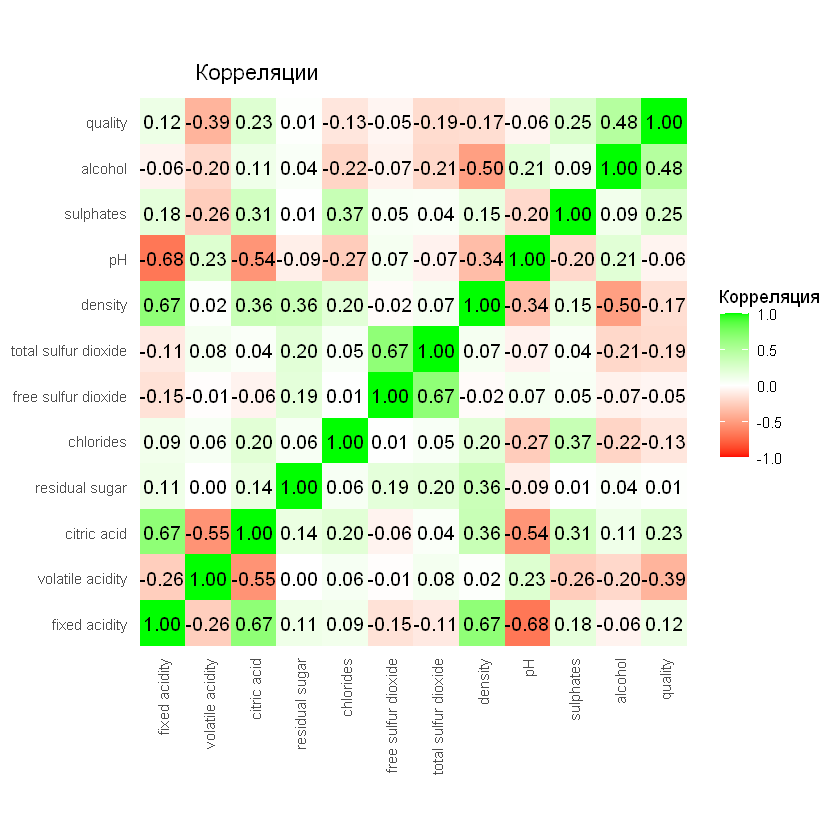

In [12]:
library(ggplot2)
library(reshape2)

# Вычисляем матрицу корреляций между всеми числовыми переменными в наборе данных
numeric_data <- data[sapply(data, is.numeric)]
correlation_matrix <- cor(numeric_data, use = "complete.obs")

# Преобразуем матрицу в длинный формат для ggplot
melted_corr <- reshape2::melt(correlation_matrix)

# Создаем тепловую карту
ggplot(data = melted_corr, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile() +
  geom_text(aes(label = sprintf("%.2f", value)), color = "black", size = 4) +
  scale_fill_gradient2(low = "red", mid = "white", high = "green", 
                       midpoint = 0, limits = c(-1, 1)) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.title = element_blank(),
    panel.grid = element_blank()
  ) +
  labs(
    title = "          Корреляции",
    fill = "Корреляция"
  ) +
  coord_fixed()

In [14]:
library(car)

numeric_data <- data[sapply(data, is.numeric)]

# Создаем матрицу предикторов (включая все переменные)
clean_names <- make.names(names(numeric_data))
X <- as.matrix(setNames(numeric_data, clean_names))

# Вычисляем VIF для каждой переменной
vif_values <- numeric(ncol(X))
names(vif_values) <- names(numeric_data)

for (i in 1:ncol(X)) {
  # Создаем модель где текущая переменная - зависимая, остальные - независимые
  y <- X[, i]
  X_other <- X[, -i, drop = FALSE]
  
  model <- lm(y ~ X_other)
  r_squared <- summary(model)$r.squared
  
  # Расчет VIF
  vif_values[i] <- 1 / (1 - r_squared)
}

# Создаем dataframe с результатами
vif_results <- data.frame(
  Переменная = names(vif_values),
  VIF = as.numeric(vif_values),
  stringsAsFactors = FALSE
)

cat("\n РЕЗУЛЬТАТЫ VIF АНАЛИЗА:\n")

for(i in 1:nrow(vif_results)) {
  variable <- vif_results$Переменная[i]
  vif_value <- vif_results$VIF[i]
  
  # Определяем статус на основе значения VIF
  if (vif_value == 1) {
    status <- "Идеально"
  } else if (vif_value < 5) {
    status <- "Норма"
  } else if (vif_value < 10) {
    status <- "Внимание      "
  } else {
    status <- "Проблема"
  }
  
  # Форматируем вывод
  var_name <- ifelse(nchar(variable) > 25, 
                     paste0(substr(variable, 1, 25), "..."), 
                     variable)
  
  cat(sprintf("   | %-30s | %8.2f   | %-19s |\n", var_name, vif_value, status))
}



 РЕЗУЛЬТАТЫ VIF АНАЛИЗА:
   | fixed acidity                  |     7.77   | Внимание       |
   | volatile acidity               |     1.88   | Норма          |
   | citric acid                    |     3.13   | Норма          |
   | residual sugar                 |     1.70   | Норма          |
   | chlorides                      |     1.50   | Норма          |
   | free sulfur dioxide            |     1.97   | Норма          |
   | total sulfur dioxide           |     2.21   | Норма          |
   | density                        |     6.35   | Внимание       |
   | pH                             |     3.34   | Норма          |
   | sulphates                      |     1.49   | Норма          |
   | alcohol                        |     3.24   | Норма          |
   | quality                        |     1.56   | Норма          |


<b>Выводы:</b>
1. Умеренная мультиколлинеарность наблюдается в переменных "fixed acidity" (VIF = 7.77) и "density" (VIF = 6.35). Это объясняется тем, что фиксированная кислотность и плотность вина являются взаимосвязанными физико-химическими параметрами, которые зависят от состава сусла и процесса брожения.
2. Низкий VIF (менее 5) у остальных переменных - "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "pH", "sulphates", "alcohol" и "quality" - подтверждает их относительную независимость в модели и отсутствие серьезных проблем мультиколлинеарности.
3. Общий уровень мультиколлинеарности в данных можно считать приемлемым для построения регрессионных моделей, так как значения VIF не превышают критического порога 10.

## 5.Исследование зависимости в данных с помощью дисперсионного анализа.

In [15]:
# Создаем категории для алкоголя
bins <- c(8, 10, 12, 14, 16)
labels <- c('8-10%', '10-12%', '12-14%', '14-16%')
data$alcohol_category <- cut(data$alcohol, breaks = bins, labels = labels)

# Проводим ANOVA анализ
anova_result <- aov(density ~ alcohol_category, data = data)

# Извлекаем F-статистику и p-значение
f_statistic <- summary(anova_result)[[1]]$"F value"[1]
p_value <- summary(anova_result)[[1]]$"Pr(>F)"[1]

# Красивый вывод результатов
cat("\n                 РЕЗУЛЬТАТЫ ANOVA ТЕСТА:\n")
cat(sprintf("   | F-статистика        | %15.2f             |\n", f_statistic))
cat(sprintf("   | P-значение          | %15.2e             |\n", p_value))


                 РЕЗУЛЬТАТЫ ANOVA ТЕСТА:
   | F-статистика        |          137.91             |
   | P-значение          |        1.93e-79             |


Дисперсионный анализ (ANOVA) был применен для исследования влияния содержания алкоголя на физические свойства вина. Выборка была разделена на четыре категории по содержанию алкоголя: 8-10%, 10-12%, 12-14% и 14-16%.

<b>Вывод:</b>
- <b>Высокое значение F-статистики (137.91)</b> свидетельствует о наличии существенных различий в средней плотности вин между различными алкогольными категориями.
- <b>Экстремально низкое p-value (1.93 × 10<sup>-79</sup>)</b> значительно ниже общепринятого уровня значимости 0.05, что дает основание отвергнуть нулевую гипотезу о равенстве средних значений плотности во всех группах.
- Статистический анализ подтверждает, что категоризация вин по содержанию алкоголя позволяет выделить группы с достоверно различными показателями плотности. Наблюдается четкая физико-химическая закономерность: увеличение концентрации алкоголя, имеющего меньшую плотность по сравнению с водой, приводит к снижению общей плотности вина.

## 6.Подогнать регрессионные модели (в том числе, нелинейные) к данным, а также оценить качество подобной аппроксимации.

In [17]:
# Устанавливаем seed для воспроизводимости
set.seed(42)

# Выбираем переменные для регрессионного анализа
filtered_data <- data[, c('quality', 'alcohol', 'density', 'volatile acidity', 'citric acid')]

# Определяем признаки (X) и целевую переменную (y)
X <- filtered_data[, c('alcohol', 'density', 'volatile acidity', 'citric acid')]
y <- filtered_data$quality

# Разделяем данные на обучающую и тестовую выборки
train_index <- sample(1:nrow(filtered_data), 0.8 * nrow(filtered_data))
X_train <- X[train_index, ]
X_test <- X[-train_index, ]
y_train <- y[train_index]
y_test <- y[-train_index]

# Обучаем линейную регрессию
linear_model <- lm(quality ~ ., data = cbind(quality = y_train, X_train))
y_pred_linear <- predict(linear_model, newdata = X_test)

# Обучаем полиномиальную регрессию (степень 3)
# Создаем полиномиальные признаки
poly_formula <- as.formula(paste("quality ~ poly(alcohol, 3) + poly(density, 3) +",
                                 "poly(`volatile acidity`, 3) + poly(`citric acid`, 3)"))
poly_model <- lm(poly_formula, data = cbind(quality = y_train, X_train))
y_pred_poly <- predict(poly_model, newdata = X_test)

# Вычисляем метрики для обеих моделей
linear_r2 <- 1 - sum((y_test - y_pred_linear)^2) / sum((y_test - mean(y_test))^2)
linear_mse <- mean((y_test - y_pred_linear)^2)

poly_r2 <- 1 - sum((y_test - y_pred_poly)^2) / sum((y_test - mean(y_test))^2)
poly_mse <- mean((y_test - y_pred_poly)^2)


cat("          СРАВНЕНИЕ ЛИНЕЙНОЙ И ПОЛИНОМИАЛЬНОЙ РЕГРЕССИИ\n\n")

cat("   | Модель                     | R2 Score     | MSE            |\n")
cat("   |                            |              |                |\n")
cat(sprintf("   | Линейная регрессия         | %12.4f | %14.4f |\n", linear_r2, linear_mse))
cat(sprintf("   | Полиномиальная (степень 3) | %12.4f | %14.4f |\n", poly_r2, poly_mse))


          СРАВНЕНИЕ ЛИНЕЙНОЙ И ПОЛИНОМИАЛЬНОЙ РЕГРЕССИИ

   | Модель                     | R2 Score     | MSE            |
   |                            |              |                |
   | Линейная регрессия         |       0.3888 |         0.4251 |
   | Полиномиальная (степень 3) |       0.3784 |         0.4323 |


**Вывод:** В отличие от ожиданий, полиномиальная модель (степень = 3) уступает линейной модели по точности (R²: 0.3784 vs 0.3888) и ошибке (MSE: 0.4323 vs 0.4251). Низкие значения R² обеих моделей (< 0.4) свидетельствуют о слабой объясняющей способности и требуют применения других подходов к моделированию данных.